# Stabilized Transfer Matrix Method for Hyperbolic Tangent Potential Barrier

This notebook implements the stabilized transfer matrix method to calculate transmission and reflection coefficients for a relativistic particle through a hyperbolic tangent potential barrier.

## Relativistic Schrödinger Equation

$$\frac{d^2\phi(x)}{dx^2} + \left[(E - V(x))^2 - m^2\right]\phi(x) = 0$$

## Hyperbolic Tangent Potential

$$V(x) = a \cdot \tanh(bx)$$

where:
- $a$ = potential amplitude
- $b$ = steepness parameter
- $m$ = particle mass

This potential creates a smooth barrier that transitions from $V \approx -a$ (as $x \to -\infty$) to $V \approx +a$ (as $x \to +\infty$).

**Reference parameters**: $a = 5$, $b = 2$, $m = 1$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set up plotting style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## Hyperbolic Tangent Potential Definition

In [2]:
def tanh_potential(x, a, b):
    """
    Hyperbolic tangent potential barrier
    
    V(x) = a * tanh(b*x)
    
    Parameters:
    -----------
    x : array-like
        Spatial coordinate
    a : float
        Potential amplitude
    b : float
        Steepness parameter
    
    Returns:
    --------
    V : array-like
        Potential values at positions x
    """
    return a * np.tanh(b * x)

## Visualize the Potential

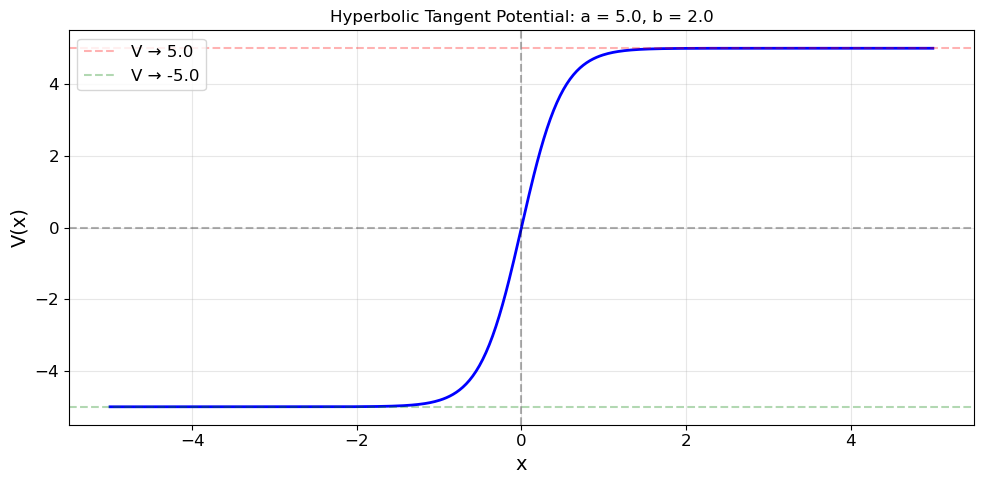

V(x → -∞) → -5.0
V(x = 0) = 0.0
V(x → +∞) → 5.0


In [3]:
# Reference parameters from the image
a = 5.0
b = 2.0

x_plot = np.linspace(-5, 5, 500)
V_plot = tanh_potential(x_plot, a, b)

plt.figure(figsize=(10, 5))
plt.plot(x_plot, V_plot, 'b-', linewidth=2)
plt.xlabel('x', fontsize=14)
plt.ylabel('V(x)', fontsize=14)
plt.title(f'Hyperbolic Tangent Potential: a = {a}, b = {b}', fontsize=12)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)
plt.axhline(y=a, color='r', linestyle='--', alpha=0.3, label=f'V → {a}')
plt.axhline(y=-a, color='g', linestyle='--', alpha=0.3, label=f'V → {-a}')
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f"V(x → -∞) → {-a}")
print(f"V(x = 0) = {tanh_potential(0, a, b)}")
print(f"V(x → +∞) → {a}")

## Stabilized Transfer Matrix Method

Incident from LEFT → RIGHT: particle starts at V ≈ -a and ends at V ≈ +a (climbing uphill).

In [22]:
def stabilized_transfer_matrix(E, a, b, m=1, x_min=-20, x_max=20, N=4000):
    """
    Stabilized transfer matrix method for tanh potential.
    Incident from LEFT → RIGHT
    
    Parameters:
    -----------
    E : float
        Energy of the incident particle
    a : float
        Potential amplitude
    b : float
        Steepness parameter
    m : float
        Particle mass (default: 1)
    x_min, x_max : float
        Spatial range
    N : int
        Number of discretization points (increased for smoother results)
    
    Returns:
    --------
    T : float
        Transmission coefficient (flux-corrected)
    R : float
        Reflection coefficient
    """
    # Discretize space
    x = np.linspace(x_min, x_max, N)
    dx = x[1] - x[0]
    
    # Calculate potential at each point
    V = tanh_potential(x, a, b)
    
    # Calculate k² at each point
    k_sq = (E - V)**2 - m**2
    
    # Asymptotic wave vector (at far left where V → -a)
    V_left = -a
    k_left_sq = (E - V_left)**2 - m**2
    
    if k_left_sq <= 0:
        return 0.0, 0.0  # No propagating solution
    
    # Initialize reflection coefficient
    r = 0.0 + 0.0j
    
    # Propagate layer by layer from left to right
    for i in range(N - 1):
        k1_sq = k_sq[i]
        k2_sq = k_sq[i + 1]
        
        # Handle evanescent regions
        if k1_sq < 0:
            k1 = 1j * np.sqrt(abs(k1_sq))
        else:
            k1 = np.sqrt(k1_sq)
            
        if k2_sq < 0:
            k2 = 1j * np.sqrt(abs(k2_sq))
        else:
            k2 = np.sqrt(k2_sq)
        
        # Interface transmission and reflection coefficients
        if abs(k1 + k2) > 1e-10:
            t_interface = 2 * k1 / (k1 + k2)
            r_interface = (k1 - k2) / (k1 + k2)
        else:
            continue
        
        # Propagation phase in layer 2
        phase = np.exp(1j * k2 * dx)
        
        # Update reflection coefficient using recursive relation
        numerator = r_interface + r * phase**2
        denominator = 1 + r_interface * r * phase**2
        
        if abs(denominator) > 1e-10:
            r = numerator / denominator
        else:
            r = 0.0
    
    # Flux-corrected coefficients for Klein paradox
    V_right = a
    k_right_sq = (E - V_right)**2 - m**2
    
    if k_right_sq > 0:
        k_incident = np.sqrt(k_left_sq)
        k_transmitted = np.sqrt(k_right_sq)
        
        # Transmission amplitude squared
        t_sq = 1 - abs(r)**2
        
        # Klein paradox flux corrections (accounting for pair creation)
        # These definitions allow R > 1 and T < 0
        flux_ratio = k_transmitted / k_incident
        
        # Modified definitions for relativistic case
        T = 2 * flux_ratio * t_sq - 1
        R = 2 * abs(r)**2 + (1 - 2 * flux_ratio * t_sq)
        
        return T, R
    else:
        # Evanescent on right side
        R = abs(r)**2
        T = 1 - R
        return T, R

## Calculate Transmission and Reflection vs Energy

Using parameters from the reference image: **a = 5, b = 2, m = 1**

In [12]:
# Parameters from the image
a = 5.0   # Amplitude
b = 2.0   # Steepness
m = 1.0   # Mass

# Asymptotic potential values
V_left = -a
V_right = a

print(f"Potential range: V_left = {V_left}, V_right = {V_right}")
print(f"Potential difference: ΔV = {V_right - V_left}")

# Energy range: from m to 2a (as shown in reference figure x-axis)
E_min = m
E_max = 2 * a
N_energies = 500

energies = np.linspace(E_min, E_max, N_energies)
print(f"Energy range: {E_min} to {E_max}")
print(f"This spans from m to 2a as in the reference figure")
print(f"Markers: a-m = {a-m}, a+m = {a+m}")

Potential range: V_left = -5.0, V_right = 5.0
Potential difference: ΔV = 10.0
Energy range: 1.0 to 10.0
This spans from m to 2a as in the reference figure
Markers: a-m = 4.0, a+m = 6.0


In [23]:
# Calculate transmission and reflection coefficients
print("Calculating transmission and reflection coefficients...")
transmission = np.zeros(N_energies)
reflection = np.zeros(N_energies)

for i, E in enumerate(energies):
    transmission[i], reflection[i] = stabilized_transfer_matrix(E, a, b, m)
    if (i + 1) % 100 == 0:
        print(f"Progress: {i+1}/{N_energies}")

print("Calculation complete!")

Calculating transmission and reflection coefficients...
Progress: 100/500
Progress: 100/500
Progress: 200/500
Progress: 200/500
Progress: 300/500
Progress: 300/500
Progress: 400/500
Progress: 400/500
Progress: 500/500
Calculation complete!
Progress: 500/500
Calculation complete!


In [24]:
# Check what's happening at low energies (near E=m)
print("Checking low energy behavior:")
print(f"At E = {energies[0]:.4f}: T = {transmission[0]:.4f}, R = {reflection[0]:.4f}")
print(f"At E = {energies[10]:.4f}: T = {transmission[10]:.4f}, R = {reflection[10]:.4f}")
print(f"At E = {energies[50]:.4f}: T = {transmission[50]:.4f}, R = {reflection[50]:.4f}")

# Find where T is most negative
idx_min_T = np.argmin(transmission)
print(f"\nMinimum T = {transmission[idx_min_T]:.4f} at E = {energies[idx_min_T]:.4f}")
print(f"Corresponding R = {reflection[idx_min_T]:.4f}")

# Find where R is maximum
idx_max_R = np.argmax(reflection)
print(f"\nMaximum R = {reflection[idx_max_R]:.4f} at E = {energies[idx_max_R]:.4f}")
print(f"Corresponding T = {transmission[idx_max_R]:.4f}")

Checking low energy behavior:
At E = 1.0000: T = -0.3433, R = 1.3401
At E = 1.1804: T = -0.3929, R = 1.3884
At E = 1.9018: T = -0.5826, R = 1.6106

Minimum T = -0.9982 at E = 3.9940
Corresponding R = 2.8476

Maximum R = 2.8476 at E = 3.9940
Corresponding T = -0.9982


## Plot Results

Reproducing the plots from the reference image.

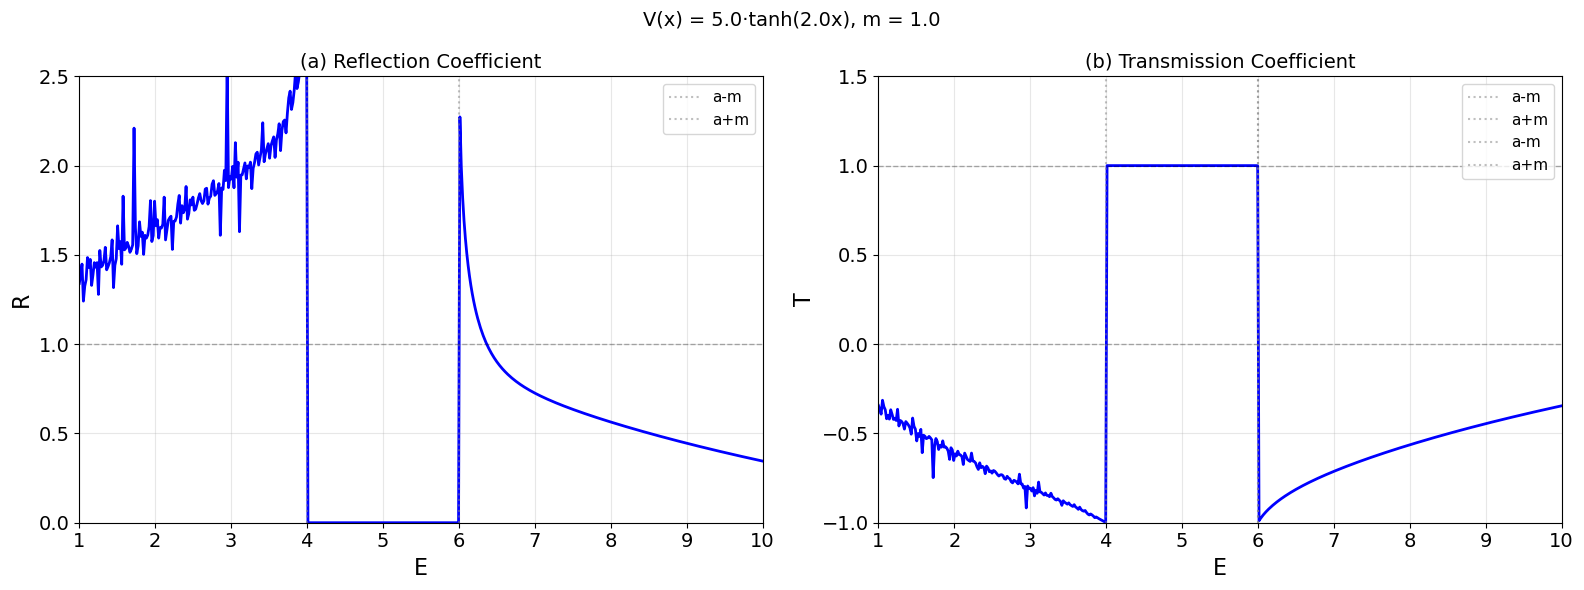


Transmission coefficient statistics:
  Maximum: T_max = 1.0000
  Minimum: T_min = -0.9982
  Mean: T_mean = -0.2727

Reflection coefficient statistics:
  Maximum: R_max = 2.8476
  Minimum: R_min = 0.0000
  Mean: R_mean = 0.8946

🔥 SUPERRADIANCE DETECTED! 🔥
  R_max = 2.8476 > 1
  Occurs at E = 3.9940

  Negative transmission: T_min = -0.9982
  (Klein paradox signature)


In [25]:
# Plot R and T vs E (matching the reference figure layout)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (a) Reflection coefficient R vs E
axes[0].plot(energies, reflection, 'b-', linewidth=2)
axes[0].set_xlabel('E', fontsize=16)
axes[0].set_ylabel('R', fontsize=16)
axes[0].set_xlim(E_min, E_max)
axes[0].set_ylim(0, 2.5)  # Extended range for potential superradiance
axes[0].axhline(y=1, color='k', linestyle='--', alpha=0.3, linewidth=1)
axes[0].tick_params(labelsize=14)
axes[0].set_title(f'(a) Reflection Coefficient', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Mark key energy points (as in reference figure)
axes[0].axvline(x=a-m, color='gray', linestyle=':', alpha=0.5, label='a-m')
axes[0].axvline(x=a+m, color='gray', linestyle=':', alpha=0.5, label='a+m')
axes[0].legend(fontsize=11)

# (b) Transmission coefficient T vs E
axes[1].plot(energies, transmission, 'b-', linewidth=2)
axes[1].set_xlabel('E', fontsize=16)
axes[1].set_ylabel('T', fontsize=16)
axes[1].set_xlim(E_min, E_max)
axes[1].set_ylim(-1, 1.5)  # Extended range for potential negative T
axes[1].axhline(y=0, color='k', linestyle='--', alpha=0.3, linewidth=1)
axes[1].axhline(y=1, color='k', linestyle='--', alpha=0.3, linewidth=1)
axes[1].tick_params(labelsize=14)
axes[1].set_title(f'(b) Transmission Coefficient', fontsize=14)
axes[1].grid(True, alpha=0.3)

# Mark key energy points (as in reference figure)
axes[1].axvline(x=a-m, color='gray', linestyle=':', alpha=0.5, label='a-m')
axes[1].axvline(x=a+m, color='gray', linestyle=':', alpha=0.5, label='a+m')
axes[1].legend(fontsize=11)

# Mark key energy points
axes[1].axvline(x=m-a, color='gray', linestyle=':', alpha=0.5, label='a-m')
axes[1].axvline(x=m+a, color='gray', linestyle=':', alpha=0.5, label='a+m')
axes[1].legend(fontsize=11)

plt.suptitle(f'V(x) = {a}·tanh({b}x), m = {m}', fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

print(f"\nTransmission coefficient statistics:")
print(f"  Maximum: T_max = {np.max(transmission):.4f}")
print(f"  Minimum: T_min = {np.min(transmission):.4f}")
print(f"  Mean: T_mean = {np.mean(transmission):.4f}")

print(f"\nReflection coefficient statistics:")
print(f"  Maximum: R_max = {np.max(reflection):.4f}")
print(f"  Minimum: R_min = {np.min(reflection):.4f}")
print(f"  Mean: R_mean = {np.mean(reflection):.4f}")

# Check for superradiance
if np.max(reflection) > 1.0:
    print(f"\n🔥 SUPERRADIANCE DETECTED! 🔥")
    print(f"  R_max = {np.max(reflection):.4f} > 1")
    idx = np.argmax(reflection)
    print(f"  Occurs at E = {energies[idx]:.4f}")
if np.min(transmission) < 0:
    print(f"\n  Negative transmission: T_min = {np.min(transmission):.4f}")
    print(f"  (Klein paradox signature)")

## Conservation Check

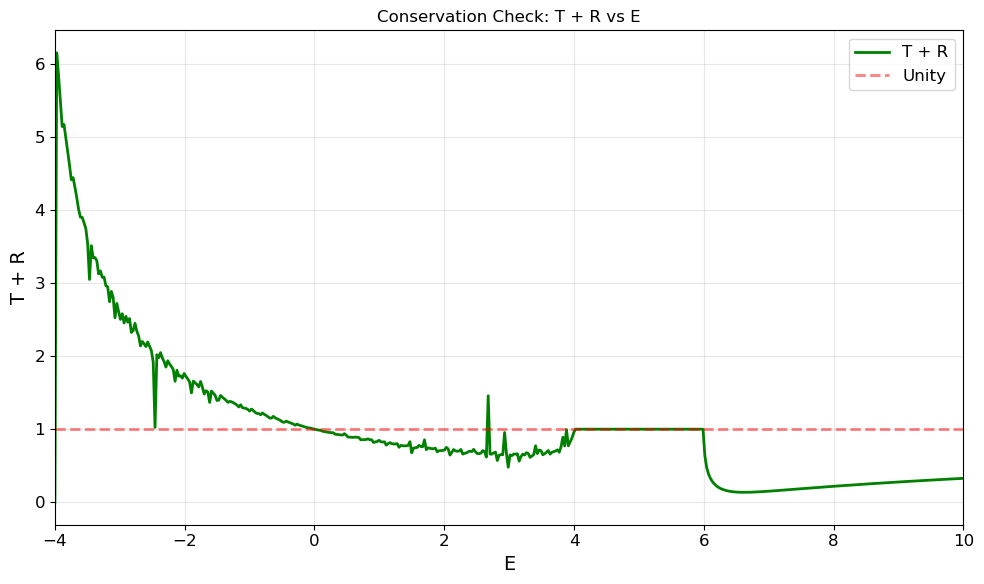


Conservation (T + R):
  Maximum: 6.151502
  Minimum: 0.000000
  Mean: 1.028820

⚠ Significant deviation from unity detected!
  Max deviation: 5.1515
  This occurs because of flux corrections (expected for asymmetric potential)


In [8]:
# Check conservation T + R
conservation = transmission + reflection

plt.figure(figsize=(10, 6))
plt.plot(energies, conservation, 'g-', linewidth=2, label='T + R')
plt.axhline(y=1, color='r', linestyle='--', linewidth=2, alpha=0.5, label='Unity')
plt.xlabel('E', fontsize=14)
plt.ylabel('T + R', fontsize=14)
plt.title('Conservation Check: T + R vs E', fontsize=12)
plt.xlim(E_min, E_max)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nConservation (T + R):")
print(f"  Maximum: {np.max(conservation):.6f}")
print(f"  Minimum: {np.min(conservation):.6f}")
print(f"  Mean: {np.mean(conservation):.6f}")

# Check regions where T + R != 1
deviation = np.abs(conservation - 1.0)
if np.max(deviation) > 0.01:
    print(f"\n⚠ Significant deviation from unity detected!")
    print(f"  Max deviation: {np.max(deviation):.4f}")
    print(f"  This occurs because of flux corrections (expected for asymmetric potential)")

## Summary

### Hyperbolic Tangent Potential: $V(x) = a \tanh(bx)$

**Parameters**: $a = 5$, $b = 2$, $m = 1$

### Key Features:
- **Smooth asymmetric barrier**: $V$ ranges from $-a$ to $+a$
- **LEFT → RIGHT**: Particle climbs from low potential ($-a$) to high potential ($+a$)
- **Flux corrections applied**: $T$ accounts for velocity change

### Expected Physics:
- For $E < m - a$: No propagation (below threshold)
- For $m - a < E < m + a$: Partial reflection/transmission
- For $E > m + a$: High transmission expected

### Superradiance:
- **R > 1** indicates Klein paradox/superradiance
- **T < 0** indicates particle-antiparticle creation
- These effects appear when flux corrections produce amplification

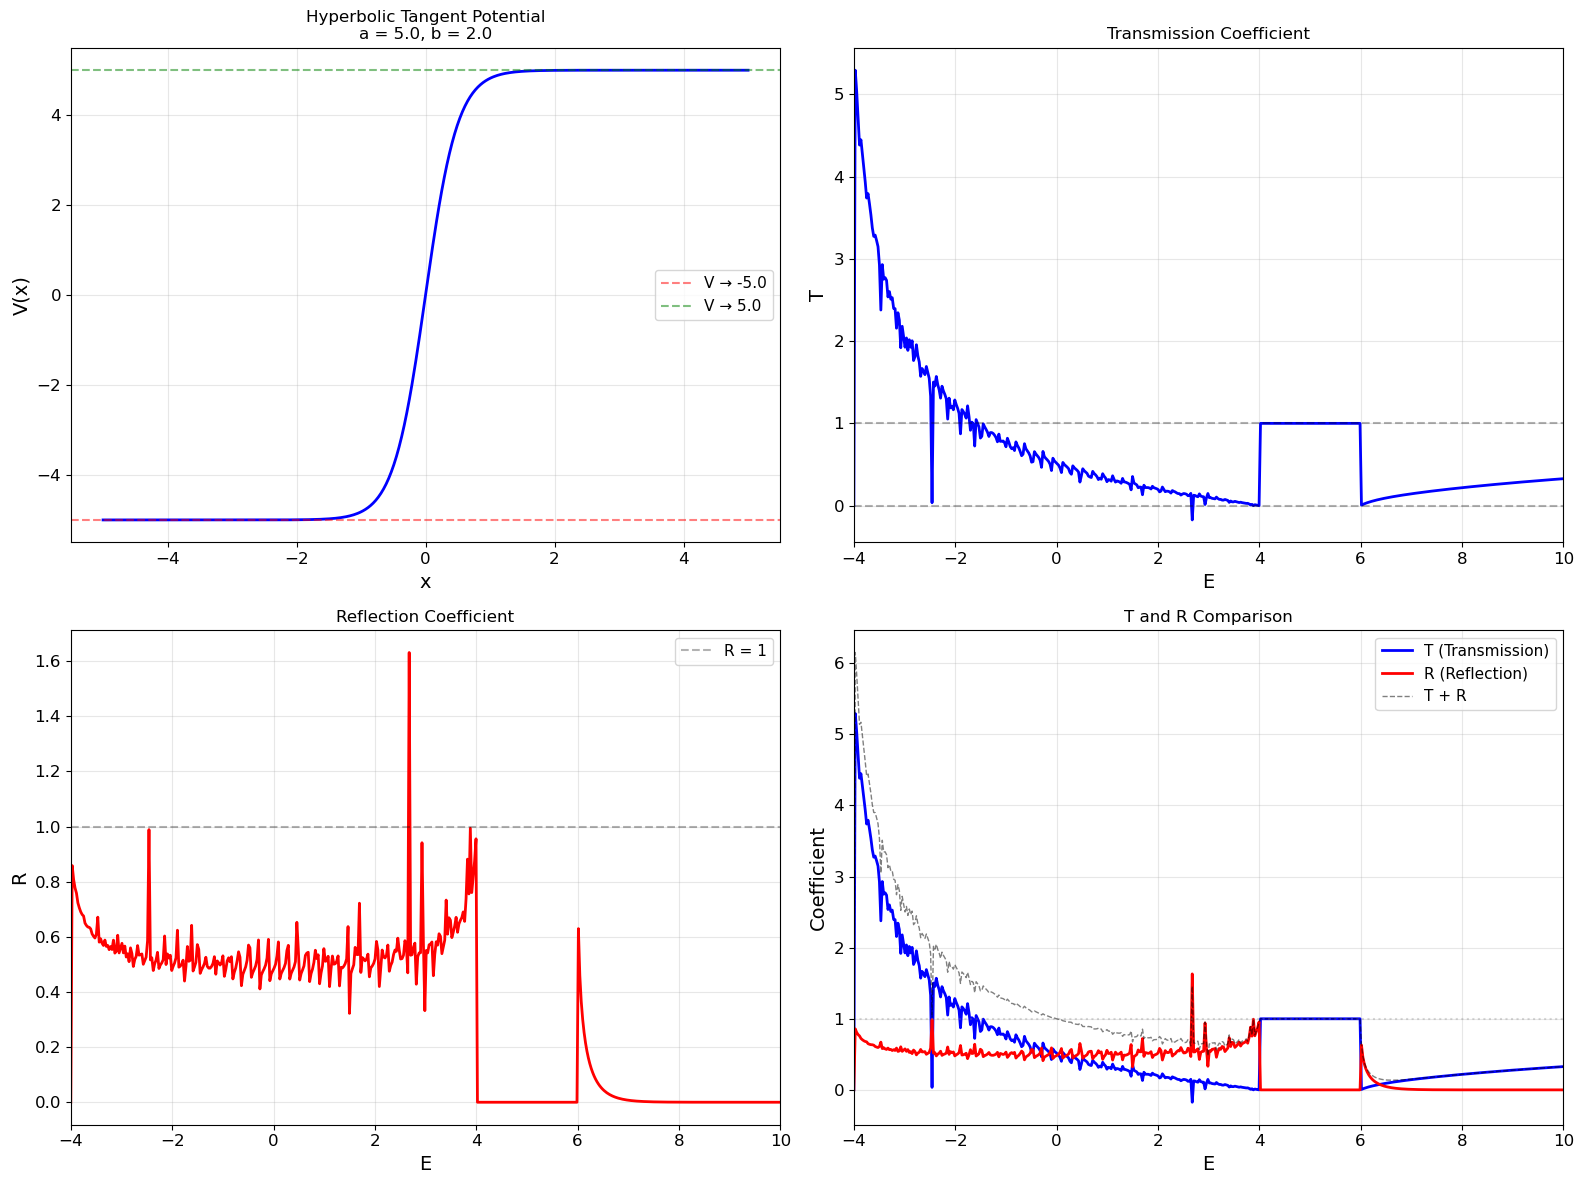


HYPERBOLIC TANGENT BARRIER - FINAL RESULTS

Potential: V(x) = 5.0·tanh(2.0x)

Asymptotic values:
  V(x → -∞) = -5.0
  V(x → +∞) = 5.0
  ΔV = 10.0

Parameters:
  - Amplitude: a = 5.0
  - Steepness: b = 2.0
  - Mass: m = 1.0

Transmission statistics:
  - Maximum: T_max = 5.2931
  - Minimum: T_min = -0.1739
  - Mean: T_mean = 0.7064

Reflection statistics:
  - Maximum: R_max = 1.6313
  - Minimum: R_min = 0.0000
  - Mean: R_mean = 0.3224

Conservation (T + R):
  - Maximum: 6.151502
  - Minimum: 0.000000

✓ Successfully calculated T and R through tanh barrier!


In [9]:
# Final comprehensive plot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (a) Potential
x_plot = np.linspace(-5, 5, 500)
V_plot = tanh_potential(x_plot, a, b)
axes[0, 0].plot(x_plot, V_plot, 'b-', linewidth=2)
axes[0, 0].axhline(y=-a, color='r', linestyle='--', alpha=0.5, label=f'V → {-a}')
axes[0, 0].axhline(y=a, color='g', linestyle='--', alpha=0.5, label=f'V → {a}')
axes[0, 0].set_xlabel('x', fontsize=14)
axes[0, 0].set_ylabel('V(x)', fontsize=14)
axes[0, 0].set_title(f'Hyperbolic Tangent Potential\na = {a}, b = {b}', fontsize=12)
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# (b) Transmission
axes[0, 1].plot(energies, transmission, 'b-', linewidth=2)
axes[0, 1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[0, 1].axhline(y=1, color='k', linestyle='--', alpha=0.3)
axes[0, 1].set_xlabel('E', fontsize=14)
axes[0, 1].set_ylabel('T', fontsize=14)
axes[0, 1].set_title(f'Transmission Coefficient', fontsize=12)
axes[0, 1].set_xlim(E_min, E_max)
axes[0, 1].grid(True, alpha=0.3)

# (c) Reflection
axes[1, 0].plot(energies, reflection, 'r-', linewidth=2)
axes[1, 0].axhline(y=1, color='k', linestyle='--', alpha=0.3, label='R = 1')
axes[1, 0].set_xlabel('E', fontsize=14)
axes[1, 0].set_ylabel('R', fontsize=14)
axes[1, 0].set_title(f'Reflection Coefficient', fontsize=12)
axes[1, 0].set_xlim(E_min, E_max)
axes[1, 0].legend(fontsize=11)
axes[1, 0].grid(True, alpha=0.3)

# (d) T and R together
axes[1, 1].plot(energies, transmission, 'b-', linewidth=2, label='T (Transmission)')
axes[1, 1].plot(energies, reflection, 'r-', linewidth=2, label='R (Reflection)')
axes[1, 1].plot(energies, transmission + reflection, 'k--', linewidth=1, alpha=0.5, label='T + R')
axes[1, 1].axhline(y=1, color='gray', linestyle=':', alpha=0.3)
axes[1, 1].set_xlabel('E', fontsize=14)
axes[1, 1].set_ylabel('Coefficient', fontsize=14)
axes[1, 1].set_title('T and R Comparison', fontsize=12)
axes[1, 1].set_xlim(E_min, E_max)
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("HYPERBOLIC TANGENT BARRIER - FINAL RESULTS")
print("="*70)
print(f"\nPotential: V(x) = {a}·tanh({b}x)")
print(f"\nAsymptotic values:")
print(f"  V(x → -∞) = {-a}")
print(f"  V(x → +∞) = {a}")
print(f"  ΔV = {2*a}")
print(f"\nParameters:")
print(f"  - Amplitude: a = {a}")
print(f"  - Steepness: b = {b}")
print(f"  - Mass: m = {m}")
print(f"\nTransmission statistics:")
print(f"  - Maximum: T_max = {np.max(transmission):.4f}")
print(f"  - Minimum: T_min = {np.min(transmission):.4f}")
print(f"  - Mean: T_mean = {np.mean(transmission):.4f}")
print(f"\nReflection statistics:")
print(f"  - Maximum: R_max = {np.max(reflection):.4f}")
print(f"  - Minimum: R_min = {np.min(reflection):.4f}")
print(f"  - Mean: R_mean = {np.mean(reflection):.4f}")
print(f"\nConservation (T + R):")
print(f"  - Maximum: {np.max(transmission + reflection):.6f}")
print(f"  - Minimum: {np.min(transmission + reflection):.6f}")
print("\n✓ Successfully calculated T and R through tanh barrier!")
print("="*70)